### Experiment #01: Deep Overparameterized MLP
- **Objective:** Test the baseline capacity of a 3-hidden-layer network on Level-0 probabilities.
- **Input Features:** 12 expert probabilities (Baseline, ECO, Momentum, ACPL).
- **Architecture:** Input (12) -> Hidden1 (64) -> Hidden2 (32) -> Hidden3 (16) -> Output (3)
- **Regularization:** None (Intentionally checking for overfitting limits).
- **Expected Outcome:** High training accuracy, sharp drop in OOF/Validation accuracy (Memorization).

--- Experiment #01: Deep Overparameterized MLP ---
Successfully joined 4912 rows containing all 4 expert predictions.
Initiating PyTorch Training Loop...
Epoch [50/200] | Train Loss: 1.0550 | Val Loss: 1.0447
Epoch [100/200] | Train Loss: 0.9890 | Val Loss: 0.9681
Epoch [150/200] | Train Loss: 0.9668 | Val Loss: 0.9243
Epoch [200/200] | Train Loss: 0.9603 | Val Loss: 0.9178


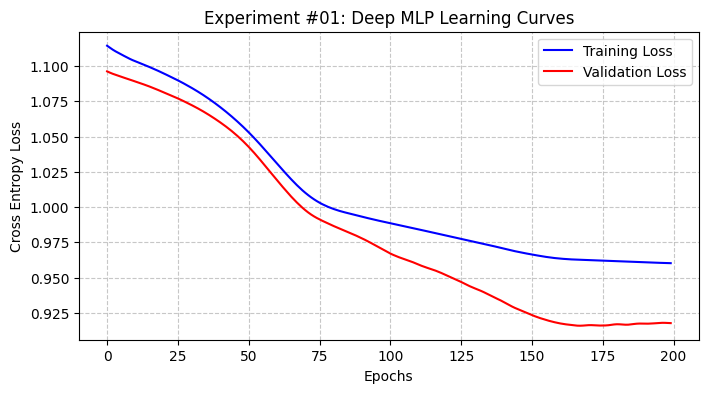


Final Validation Accuracy: 59.31%


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("--- Experiment #01: Deep Overparameterized MLP ---")

# 1. Fetch and Join all 4 Level-0 Experts
conn = sqlite3.connect('../data/omni_pundit.db')
query = """
    SELECT 
        b.target_result,
        base.base_oof_prob_black, base.base_oof_prob_draw, base.base_oof_prob_white,
        eco.eco_oof_prob_black, eco.eco_oof_prob_draw, eco.eco_oof_prob_white,
        mom.momentum_oof_prob_black, mom.momentum_oof_prob_draw, mom.momentum_oof_prob_white,
        acpl.acpl_oof_prob_black, acpl.acpl_oof_prob_draw, acpl.acpl_oof_prob_white
    FROM oof_predictions_baseline base
    JOIN oof_predictions_eco eco ON base.game_id = eco.game_id
    JOIN oof_predictions_momentum mom ON base.game_id = mom.game_id
    JOIN oof_predictions_acpl acpl ON base.game_id = acpl.game_id
    JOIN baseline_features b ON base.game_id = b.game_id
    ORDER BY b.date ASC
"""
df_meta = pd.read_sql(query, conn)
conn.close()

print(f"Successfully joined {len(df_meta)} rows containing all 4 expert predictions.")

# 2. Data Preparation
feature_cols = [col for col in df_meta.columns if col != 'target_result']
X = df_meta[feature_cols].values
y = df_meta['target_result'].map({-1: 0, 0: 1, 1: 2}).values

# Chronological split for the experiment (80% Train, 20% Validation)
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# Convert to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)

# 3. Define the Deep Neural Network Architecture
class DeepMLP(nn.Module):
    def __init__(self, input_size):
        super(DeepMLP, self).__init__()
        # 3 Hidden Layers, No Dropout (Intentionally prone to overfitting)
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3) # 3 Output classes
        )

    def forward(self, x):
        return self.network(x)

# 4. Initialize Model, Loss Function, and Optimizer
model = DeepMLP(input_size=12)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop with History Tracking
epochs = 200
train_losses = []
val_losses = []

print("Initiating PyTorch Training Loop...")

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())
        
    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

# 6. Plotting the Learning Curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Experiment #01: Deep MLP Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Final Accuracy Check
with torch.no_grad():
    _, predicted = torch.max(val_outputs, 1)
    acc = (predicted == y_val_tensor).sum().item() / len(y_val_tensor)
    print(f"\nFinal Validation Accuracy: {acc * 100:.2f}%")

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

print("--- Experiment #02: Linear Benchmark vs Regularized Stacker ---")

# 1. Fetch data (Identical subset to Exp #01)
conn = sqlite3.connect('../data/omni_pundit.db')
query = """
    SELECT 
        b.target_result,
        base.base_oof_prob_black, base.base_oof_prob_draw, base.base_oof_prob_white,
        eco.eco_oof_prob_black, eco.eco_oof_prob_draw, eco.eco_oof_prob_white,
        mom.momentum_oof_prob_black, mom.momentum_oof_prob_draw, mom.momentum_oof_prob_white,
        acpl.acpl_oof_prob_black, acpl.acpl_oof_prob_draw, acpl.acpl_oof_prob_white
    FROM oof_predictions_baseline base
    JOIN oof_predictions_eco eco ON base.game_id = eco.game_id
    JOIN oof_predictions_momentum mom ON base.game_id = mom.game_id
    JOIN oof_predictions_acpl acpl ON base.game_id = acpl.game_id
    JOIN baseline_features b ON base.game_id = b.game_id
    ORDER BY b.date ASC
"""
df_meta = pd.read_sql(query, conn)
conn.close()

X = df_meta[[c for c in df_meta.columns if c != 'target_result']].values
y = df_meta['target_result'].map({-1: 0, 0: 1, 1: 2}).values

split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# --- PART A: Logistic Regression Benchmark ---
lr_bench = LogisticRegression(max_iter=1000, solver='lbfgs')
lr_bench.fit(X_train, y_train)
lr_preds = lr_bench.predict(X_val)
lr_acc = accuracy_score(y_val, lr_preds)
print(f"Logistic Regression Benchmark Accuracy on this slice: {lr_acc * 100:.2f}%")

# --- PART B: Regularized Wide & Shallow PyTorch Network ---
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)

class RegularizedShallowNN(nn.Module):
    def __init__(self, input_size):
        super(RegularizedShallowNN, self).__init__()
        # 1 Hidden Layer, High Dropout to force generalization
        self.layer1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.4)
        self.out = nn.Linear(16, 3)

    def forward(self, x):
        x = self.dropout(self.relu(self.layer1(x)))
        return self.out(x)

model = RegularizedShallowNN(input_size=12)
criterion = nn.CrossEntropyLoss()
# Added Weight Decay (L2 Regularization) to prevent coefficient explosion
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    val_outputs = model(X_val_t)
    _, predicted = torch.max(val_outputs, 1)
    nn_acc = (predicted == y_val_t).sum().item() / len(y_val_t)

print(f"Regularized Shallow NN Accuracy on this slice: {nn_acc * 100:.2f}%")

--- Experiment #02: Linear Benchmark vs Regularized Stacker ---
Logistic Regression Benchmark Accuracy on this slice: 59.72%
Regularized Shallow NN Accuracy on this slice: 57.27%


In [5]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("--- Experiment #03: Wide & Deep Stacker (170k+ Rows) ---")

# 1. Fetch data (Removed mom.form_diff since we didn't save it to SQLite)
conn = sqlite3.connect('../data/omni_pundit.db')
query = """
    SELECT 
        b.target_result, b.elo_diff,
        base.base_oof_prob_black, base.base_oof_prob_draw, base.base_oof_prob_white,
        eco.eco_oof_prob_black, eco.eco_oof_prob_draw, eco.eco_oof_prob_white,
        mom.momentum_oof_prob_black, mom.momentum_oof_prob_draw, mom.momentum_oof_prob_white
    FROM oof_predictions_baseline base
    JOIN oof_predictions_eco eco ON base.game_id = eco.game_id
    JOIN oof_predictions_momentum mom ON base.game_id = mom.game_id
    JOIN baseline_features b ON base.game_id = b.game_id
    ORDER BY b.date ASC
"""
df_meta = pd.read_sql(query, conn)
conn.close()

print(f"Successfully joined {len(df_meta)} rows for Wide & Deep training.")

# 2. Separate Features into "Wide" (Context) and "Deep" (Probabilities)
wide_cols = ['elo_diff']  # Using just Elo difference as our contextual anchor
deep_cols = [c for c in df_meta.columns if 'oof_prob' in c]

X_wide = df_meta[wide_cols].values
X_deep = df_meta[deep_cols].values
y = df_meta['target_result'].map({-1: 0, 0: 1, 1: 2}).values

# 3. Chronological Split (80/20)
split_idx = int(len(y) * 0.8)
X_wide_train, X_wide_val = X_wide[:split_idx], X_wide[split_idx:]
X_deep_train, X_deep_val = X_deep[:split_idx], X_deep[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# 4. Scale the Wide Context features
scaler = StandardScaler()
X_wide_train = scaler.fit_transform(X_wide_train)
X_wide_val = scaler.transform(X_wide_val)

# Convert to Tensors
t_wide_train = torch.FloatTensor(X_wide_train)
t_deep_train = torch.FloatTensor(X_deep_train)
t_y_train = torch.LongTensor(y_train)

t_wide_val = torch.FloatTensor(X_wide_val)
t_deep_val = torch.FloatTensor(X_deep_val)
t_y_val = torch.LongTensor(y_val)

# 5. The Wide & Deep Architecture
class WideAndDeep(nn.Module):
    def __init__(self, deep_in, wide_in, hidden_size=16):
        super(WideAndDeep, self).__init__()
        # Deep Path (For Probabilities)
        self.deep_path = nn.Sequential(
            nn.Linear(deep_in, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        # Combined Output (Deep Output + Wide Raw Context)
        self.output_layer = nn.Linear(hidden_size + wide_in, 3)

    def forward(self, wide_x, deep_x):
        deep_out = self.deep_path(deep_x)
        # Concatenate the processed probabilities with the raw context features
        combined = torch.cat((deep_out, wide_x), dim=1)
        return self.output_layer(combined)

# wide_in is 1 because we are only passing elo_diff
model = WideAndDeep(deep_in=9, wide_in=1)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 6. Training Loop
epochs = 150

print("Training Wide & Deep PyTorch Network...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(t_wide_train, t_deep_train)
    loss = criterion(outputs, t_y_train)
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(t_wide_val, t_deep_val)

# 7. Evaluate
with torch.no_grad():
    _, predicted = torch.max(val_outputs, 1)
    acc = (predicted == t_y_val).sum().item() / len(t_y_val)
    print(f"\nWide & Deep Final Validation Accuracy: {acc * 100:.2f}%")

--- Experiment #03: Wide & Deep Stacker (170k+ Rows) ---
Successfully joined 171370 rows for Wide & Deep training.
Training Wide & Deep PyTorch Network...

Wide & Deep Final Validation Accuracy: 60.82%


In [7]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("--- Experiment #04: Wide & Deep + Psychological Context ---")

# 1. Fetch the raw timeline data to calculate Psychology metrics
conn = sqlite3.connect('../data/omni_pundit.db')
query = """
    SELECT 
        b.game_id, b.date, b.white, b.black, b.target_result, b.elo_diff,
        base.base_oof_prob_black, base.base_oof_prob_draw, base.base_oof_prob_white,
        eco.eco_oof_prob_black, eco.eco_oof_prob_draw, eco.eco_oof_prob_white,
        mom.momentum_oof_prob_black, mom.momentum_oof_prob_draw, mom.momentum_oof_prob_white
    FROM oof_predictions_baseline base
    JOIN oof_predictions_eco eco ON base.game_id = eco.game_id
    JOIN oof_predictions_momentum mom ON base.game_id = mom.game_id
    JOIN baseline_features b ON base.game_id = b.game_id
    ORDER BY b.date ASC
"""
df_meta = pd.read_sql(query, conn)
conn.close()

df_meta['date'] = pd.to_datetime(df_meta['date'])

# 2. Engineer Psychological Features (Tilt, Fatigue, Rest)
print("Engineering Psychological Context (Tilt & Fatigue)...")
player_timeline = []
for row in df_meta.itertuples():
    player_timeline.append({'game_id': row.game_id, 'date': row.date, 'player': row.white, 'color': 'white', 'result': 1 if row.target_result == 1 else 0})
    player_timeline.append({'game_id': row.game_id, 'date': row.date, 'player': row.black, 'color': 'black', 'result': 1 if row.target_result == -1 else 0})

# Sort by player and date first to guarantee chronological order for rolling math
pdf = pd.DataFrame(player_timeline).sort_values(['player', 'date']).copy()

# Calculate Days Since Last Game (Rust)
pdf['prev_date'] = pdf.groupby('player')['date'].shift(1)
pdf['rest_days'] = (pdf['date'] - pdf['prev_date']).dt.days.fillna(30) # Default 30 days for first game
pdf['rest_days'] = np.clip(pdf['rest_days'], 0, 90) # Cap at 90 days

# Calculate Fatigue (Games in last 7 days)
pdf = pdf.set_index('date')
# By extracting .values, we bypass Pandas index-alignment and the duplicate-date error entirely
fatigue_values = pdf.groupby('player')['game_id'].rolling('7D').count().values - 1
pdf['fatigue_7d'] = fatigue_values
pdf = pdf.reset_index()

# Calculate Tilt (Consecutive Losses)
# 1 if won, 0 if draw/loss. We want consecutive 0s.
pdf['loss_flag'] = (pdf['result'] == 0).astype(int)
pdf['tilt_streak'] = pdf.groupby('player')['loss_flag'].transform(lambda x: x * (x.groupby((x != x.shift()).cumsum()).cumcount() + 1))
pdf['tilt_streak'] = pdf.groupby('player')['tilt_streak'].shift(1).fillna(0)

# Re-sort chronologically for merging
pdf = pdf.sort_values('date')

# Merge Context back to Meta DataFrame
w_context = pdf[pdf['color'] == 'white'][['game_id', 'rest_days', 'fatigue_7d', 'tilt_streak']].rename(
    columns={'rest_days': 'w_rest', 'fatigue_7d': 'w_fatigue', 'tilt_streak': 'w_tilt'})
b_context = pdf[pdf['color'] == 'black'][['game_id', 'rest_days', 'fatigue_7d', 'tilt_streak']].rename(
    columns={'rest_days': 'b_rest', 'fatigue_7d': 'b_fatigue', 'tilt_streak': 'b_tilt'})

df_meta = df_meta.merge(w_context, on='game_id', how='left')
df_meta = df_meta.merge(b_context, on='game_id', how='left')

# Differential Features for the Neural Network
df_meta['rest_diff'] = df_meta['w_rest'] - df_meta['b_rest']
df_meta['fatigue_diff'] = df_meta['w_fatigue'] - df_meta['b_fatigue']
df_meta['tilt_diff'] = df_meta['w_tilt'] - df_meta['b_tilt']

df_meta.dropna(inplace=True)

# 3. Setup Wide & Deep Tensors
# We now have FOUR massive context features for the Wide Layer
wide_cols = ['elo_diff', 'rest_diff', 'fatigue_diff', 'tilt_diff'] 
deep_cols = [c for c in df_meta.columns if 'oof_prob' in c]

X_wide = df_meta[wide_cols].values
X_deep = df_meta[deep_cols].values
y = df_meta['target_result'].map({-1: 0, 0: 1, 1: 2}).values

split_idx = int(len(y) * 0.8)
X_wide_train, X_wide_val = X_wide[:split_idx], X_wide[split_idx:]
X_deep_train, X_deep_val = X_deep[:split_idx], X_deep[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_wide_train = scaler.fit_transform(X_wide_train)
X_wide_val = scaler.transform(X_wide_val)

t_wide_train = torch.FloatTensor(X_wide_train)
t_deep_train = torch.FloatTensor(X_deep_train)
t_y_train = torch.LongTensor(y_train)

t_wide_val = torch.FloatTensor(X_wide_val)
t_deep_val = torch.FloatTensor(X_deep_val)
t_y_val = torch.LongTensor(y_val)

# 4. Neural Network Definition
class WideAndDeepContext(nn.Module):
    def __init__(self, deep_in, wide_in, hidden_size=24):
        super(WideAndDeepContext, self).__init__()
        self.deep_path = nn.Sequential(
            nn.Linear(deep_in, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.output_layer = nn.Linear(hidden_size + wide_in, 3)

    def forward(self, wide_x, deep_x):
        deep_out = self.deep_path(deep_x)
        combined = torch.cat((deep_out, wide_x), dim=1)
        return self.output_layer(combined)

model = WideAndDeepContext(deep_in=9, wide_in=4)  # wide_in is now 4!
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 5. Training Loop
print("Training Psych-Context Wide & Deep Network...")
epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(t_wide_train, t_deep_train)
    loss = criterion(outputs, t_y_train)
    loss.backward()
    optimizer.step()
    
model.eval()
with torch.no_grad():
    val_outputs = model(t_wide_val, t_deep_val)
    _, predicted = torch.max(val_outputs, 1)
    acc = (predicted == t_y_val).sum().item() / len(t_y_val)
    print(f"\nFinal Validation Accuracy (With Psych Context): {acc * 100:.2f}%")

--- Experiment #04: Wide & Deep + Psychological Context ---
Engineering Psychological Context (Tilt & Fatigue)...
Training Psych-Context Wide & Deep Network...

Final Validation Accuracy (With Psych Context): 63.07%


In [8]:
import sqlite3
import pandas as pd

DB_PATH = '../data/omni_pundit.db'

def check_expert_correlation():
    print("--- Checking correlation between base expert OOF predictions ---")
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT
            base.base_oof_prob_white, base.base_oof_prob_draw, base.base_oof_prob_black,
            eco.eco_oof_prob_white, eco.eco_oof_prob_draw, eco.eco_oof_prob_black,
            mom.momentum_oof_prob_white, mom.momentum_oof_prob_draw, mom.momentum_oof_prob_black
        FROM oof_predictions_baseline base
        JOIN oof_predictions_eco eco ON base.game_id = eco.game_id
        JOIN oof_predictions_momentum mom ON base.game_id = mom.game_id
    """
    df = pd.read_sql(query, conn)
    conn.close()

    print(f"Rows compared: {len(df)}\n")

    # Focus on P(White Win) from each expert - if two experts are giving
    # near-identical opinions on the same games, the meta-learner isn't
    # getting 9 independent signals, it's getting fewer, no matter how big
    # the network is. This tells you whether the ceiling right now is
    # architecture-bound or information-bound.
    white_prob_cols = ['base_oof_prob_white', 'eco_oof_prob_white', 'momentum_oof_prob_white']
    corr_white = df[white_prob_cols].corr()
    print("Correlation matrix - P(White Win) across experts:")
    print(corr_white.round(3))
    print()

    full_corr = df.corr()
    print("Full 9x9 correlation matrix (all classes, all experts):")
    print(full_corr.round(2))
    print()

    # Flag any cross-expert pair above 0.85 - a rough "these two are saying
    # almost the same thing" threshold. We deliberately skip same-expert
    # pairs (e.g. base_white vs base_black) since those are trivially
    # anti-correlated by construction - they're compositional (roughly sum
    # to 1 with draw), so a strong correlation there is meaningless noise,
    # not a sign of redundant experts.
    print("Cross-expert pairs with |correlation| > 0.85 (excluding same-expert pairs):")
    flagged = False
    cols = full_corr.columns

    def expert_of(col):
        return col.split('_oof_prob_')[0]

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if expert_of(cols[i]) == expert_of(cols[j]):
                continue  # same expert, skip - see comment above
            val = full_corr.iloc[i, j]
            if abs(val) > 0.85:
                print(f"  {cols[i]}  <->  {cols[j]}:  {val:.3f}")
                flagged = True
    if not flagged:
        print("  None found - experts appear reasonably decorrelated.")

if __name__ == "__main__":
    check_expert_correlation()

--- Checking correlation between base expert OOF predictions ---
Rows compared: 171370

Correlation matrix - P(White Win) across experts:
                         base_oof_prob_white  eco_oof_prob_white  \
base_oof_prob_white                    1.000               0.965   
eco_oof_prob_white                     0.965               1.000   
momentum_oof_prob_white                0.864               0.861   

                         momentum_oof_prob_white  
base_oof_prob_white                        0.864  
eco_oof_prob_white                         0.861  
momentum_oof_prob_white                    1.000  

Full 9x9 correlation matrix (all classes, all experts):
                         base_oof_prob_white  base_oof_prob_draw  \
base_oof_prob_white                     1.00               -0.46   
base_oof_prob_draw                     -0.46                1.00   
base_oof_prob_black                    -0.82               -0.13   
eco_oof_prob_white                      0.96            

In [9]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import TimeSeriesSplit
import pickle
import os

print("--- Training Meta-Learner V2 (Wide & Deep + Psych Context) ---")

DB_PATH = '../data/omni_pundit.db'
MODEL_PATH = '../saved_models/meta_learner_wide_deep.pkl'

# ============================================================
# 1. Load & engineer features (unchanged from your Experiment #04)
# ============================================================
conn = sqlite3.connect(DB_PATH)
query = """
    SELECT
        b.game_id, b.date, b.white, b.black, b.target_result, b.elo_diff,
        base.base_oof_prob_black, base.base_oof_prob_draw, base.base_oof_prob_white,
        eco.eco_oof_prob_black, eco.eco_oof_prob_draw, eco.eco_oof_prob_white,
        mom.momentum_oof_prob_black, mom.momentum_oof_prob_draw, mom.momentum_oof_prob_white
    FROM oof_predictions_baseline base
    JOIN oof_predictions_eco eco ON base.game_id = eco.game_id
    JOIN oof_predictions_momentum mom ON base.game_id = mom.game_id
    JOIN baseline_features b ON base.game_id = b.game_id
    ORDER BY b.date ASC
"""
df_meta = pd.read_sql(query, conn)
conn.close()

df_meta['date'] = pd.to_datetime(df_meta['date'])

print("Engineering Psychological Context (Tilt & Fatigue)...")
player_timeline = []
for row in df_meta.itertuples():
    player_timeline.append({'game_id': row.game_id, 'date': row.date, 'player': row.white,
                             'color': 'white',
                             'result_class': 1 if row.target_result == 1 else (0 if row.target_result == 0 else -1)})
    player_timeline.append({'game_id': row.game_id, 'date': row.date, 'player': row.black,
                             'color': 'black',
                             'result_class': 1 if row.target_result == -1 else (0 if row.target_result == 0 else -1)})

pdf = pd.DataFrame(player_timeline).sort_values(['player', 'date']).copy()

pdf['prev_date'] = pdf.groupby('player')['date'].shift(1)
pdf['rest_days'] = (pdf['date'] - pdf['prev_date']).dt.days.fillna(30)
pdf['rest_days'] = np.clip(pdf['rest_days'], 0, 90)

pdf = pdf.set_index('date')
fatigue_values = pdf.groupby('player')['game_id'].rolling('7D').count().values - 1
pdf['fatigue_7d'] = fatigue_values
pdf = pdf.reset_index()

# FIX: tilt should only accumulate on genuine losses (result_class == -1),
# not draws. Draws at GM level - especially with Black - are often a
# deliberate strategic choice, not a symptom of "tilt". Lumping them in
# with losses diluted the signal this feature was meant to capture.
pdf['loss_flag'] = (pdf['result_class'] == -1).astype(int)
pdf['tilt_streak'] = pdf.groupby('player')['loss_flag'].transform(
    lambda x: x * (x.groupby((x != x.shift()).cumsum()).cumcount() + 1)
)
pdf['tilt_streak'] = pdf.groupby('player')['tilt_streak'].shift(1).fillna(0)

# NEW: separate feature for draw tendency specifically with Black - a
# distinct signal from tilt, since a player drawing on purpose isn't in
# the same psychological state as a player who's been losing.
pdf['draw_flag'] = (pdf['result_class'] == 0).astype(int)
pdf['black_draw_flag'] = np.where(pdf['color'] == 'black', pdf['draw_flag'], np.nan)
pdf['black_draw_rate_10'] = pdf.groupby('player')['black_draw_flag'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
)
pdf['black_draw_rate_10'] = pdf['black_draw_rate_10'].fillna(0.0)

pdf = pdf.sort_values('date')

w_context = pdf[pdf['color'] == 'white'][['game_id', 'rest_days', 'fatigue_7d', 'tilt_streak']].rename(
    columns={'rest_days': 'w_rest', 'fatigue_7d': 'w_fatigue', 'tilt_streak': 'w_tilt'})
b_context = pdf[pdf['color'] == 'black'][['game_id', 'rest_days', 'fatigue_7d', 'tilt_streak', 'black_draw_rate_10']].rename(
    columns={'rest_days': 'b_rest', 'fatigue_7d': 'b_fatigue', 'tilt_streak': 'b_tilt'})

df_meta = df_meta.merge(w_context, on='game_id', how='left')
df_meta = df_meta.merge(b_context, on='game_id', how='left')

df_meta['rest_diff'] = df_meta['w_rest'] - df_meta['b_rest']
df_meta['fatigue_diff'] = df_meta['w_fatigue'] - df_meta['b_fatigue']
df_meta['tilt_diff'] = df_meta['w_tilt'] - df_meta['b_tilt']
# black_draw_rate_10 is Black-specific (asymmetric by design - White doesn't
# have a symmetrical "plays for draws" convention the same way), kept as its
# own feature rather than forced into a diff.

df_meta.dropna(inplace=True)
df_meta = df_meta.sort_values('date').reset_index(drop=True)

wide_cols = ['elo_diff', 'rest_diff', 'fatigue_diff', 'tilt_diff', 'black_draw_rate_10']
deep_cols = [c for c in df_meta.columns if 'oof_prob' in c]

print(f"Wide features ({len(wide_cols)}): {wide_cols}")
print(f"Deep features ({len(deep_cols)}): {deep_cols}")

X_wide_all = df_meta[wide_cols].values
X_deep_all = df_meta[deep_cols].values
y_all = df_meta['target_result'].map({-1: 0, 0: 1, 1: 2}).values

# ============================================================
# 2. Model definition
# ============================================================
class WideAndDeepContext(nn.Module):
    def __init__(self, deep_in, wide_in, hidden_size=24, combined_hidden=16):
        super().__init__()
        self.deep_path = nn.Sequential(
            nn.Linear(deep_in, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        # FIX: previously the concatenated (deep_out + wide) vector went
        # straight into a single Linear -> that's a purely linear
        # combination, meaning the network could never learn interactions
        # like "when tilt is high, weight the Momentum expert more."
        # Adding one more hidden layer after the concat gives it room to
        # actually learn those cross-terms, which is the whole point of
        # Wide & Deep.
        self.combine = nn.Sequential(
            nn.Linear(hidden_size + wide_in, combined_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(combined_hidden, 3)
        )

    def forward(self, wide_x, deep_x):
        deep_out = self.deep_path(deep_x)
        combined = torch.cat((deep_out, wide_x), dim=1)
        return self.combine(combined)


def train_one_fold(X_wide_train, X_deep_train, y_train, X_wide_val, X_deep_val, y_val,
                    max_epochs=200, patience=15, batch_size=512):
    scaler = StandardScaler()
    X_wide_train_scaled = scaler.fit_transform(X_wide_train)
    X_wide_val_scaled = scaler.transform(X_wide_val)

    t_wide_train = torch.FloatTensor(X_wide_train_scaled.copy())
    t_deep_train = torch.FloatTensor(X_deep_train.copy())
    t_y_train = torch.LongTensor(y_train.copy())

    t_wide_val = torch.FloatTensor(X_wide_val_scaled.copy())
    t_deep_val = torch.FloatTensor(X_deep_val.copy())
    t_y_val = torch.LongTensor(y_val.copy())

    # FIX: previously one gradient step per epoch over the ENTIRE training
    # set (full-batch GD). Mini-batches with shuffling introduce useful
    # gradient noise that generally helps generalization at this data size,
    # and is the standard approach for a reason.
    train_ds = TensorDataset(t_wide_train, t_deep_train, t_y_train)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model = WideAndDeepContext(deep_in=t_deep_train.shape[1], wide_in=t_wide_train.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # FIX: previously trained a fixed 200 epochs with zero validation
    # tracking during training - no way to know if it overfit at epoch 60
    # and got worse by 200. Now we track val loss every epoch, keep the
    # best-performing weights, and stop early if it stops improving.
    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        for wide_batch, deep_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(wide_batch, deep_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(t_wide_val, t_deep_val)
            val_loss = criterion(val_outputs, t_y_val).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_outputs = model(t_wide_val, t_deep_val)
        val_probs = torch.softmax(val_outputs, dim=1).numpy()
        _, predicted = torch.max(val_outputs, 1)
        acc = (predicted.numpy() == y_val).mean()

    return model, scaler, acc, val_probs, best_val_loss, epoch + 1


# ============================================================
# 3. Walk-forward validation (previously a single static 80/20 split -
# every other layer in the pipeline uses TimeSeriesSplit, this brings the
# meta-learner in line so results are comparable and not a lucky/unlucky
# single slice)
# ============================================================
tscv = TimeSeriesSplit(n_splits=4)  # cheap model - could go higher, 4 is a reasonable start
fold_accs = []
fold_log_losses = []
fold_epochs = []

print("\nRunning walk-forward validation...")
for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X_wide_all), start=1):
    model, scaler, acc, val_probs, val_loss, epochs_run = train_one_fold(
        X_wide_all[train_idx], X_deep_all[train_idx], y_all[train_idx],
        X_wide_all[val_idx], X_deep_all[val_idx], y_all[val_idx]
    )
    ll = log_loss(y_all[val_idx], val_probs, labels=[0, 1, 2])
    fold_accs.append(acc)
    fold_log_losses.append(ll)
    fold_epochs.append(epochs_run)
    print(f"  Fold {fold_num}: acc={acc*100:.2f}%  log_loss={ll:.4f}  "
          f"(stopped after {epochs_run} epochs, val set size={len(val_idx)})")

print(f"\nWalk-forward mean accuracy:  {np.mean(fold_accs)*100:.2f}%  (std: {np.std(fold_accs)*100:.2f}%)")
print(f"Walk-forward mean log loss:  {np.mean(fold_log_losses):.4f}  (std: {np.std(fold_log_losses):.4f})")
print("(The std tells you how much this number would've swung on a different single split -")
print(" a wide std means the old single-split 63.07% could easily have been a lucky draw.)")

# ============================================================
# 4. Train final model on ALL available data, held out last fold's
#    proportion as final validation for calibration reporting
# ============================================================
final_split = int(len(X_wide_all) * 0.85)
final_model, final_scaler, final_acc, final_probs, final_val_loss, _ = train_one_fold(
    X_wide_all[:final_split], X_deep_all[:final_split], y_all[:final_split],
    X_wide_all[final_split:], X_deep_all[final_split:], y_all[final_split:]
)
print(f"\nFinal model (trained on 85%, held out last 15%): "
      f"acc={final_acc*100:.2f}%  val_log_loss={final_val_loss:.4f}")

os.makedirs('../saved_models', exist_ok=True)
with open(MODEL_PATH, 'wb') as f:
    pickle.dump({
        'model_state_dict': final_model.state_dict(),
        'wide_scaler': final_scaler,
        'wide_cols': wide_cols,
        'deep_cols': deep_cols,
        'deep_in': len(deep_cols),
        'wide_in': len(wide_cols),
    }, f)

print(f"Success! Meta-learner saved to {MODEL_PATH}")

--- Training Meta-Learner V2 (Wide & Deep + Psych Context) ---
Engineering Psychological Context (Tilt & Fatigue)...
Wide features (5): ['elo_diff', 'rest_diff', 'fatigue_diff', 'tilt_diff', 'black_draw_rate_10']
Deep features (9): ['base_oof_prob_black', 'base_oof_prob_draw', 'base_oof_prob_white', 'eco_oof_prob_black', 'eco_oof_prob_draw', 'eco_oof_prob_white', 'momentum_oof_prob_black', 'momentum_oof_prob_draw', 'momentum_oof_prob_white']

Running walk-forward validation...
  Fold 1: acc=58.73%  log_loss=0.9196  (stopped after 24 epochs, val set size=34274)
  Fold 2: acc=59.66%  log_loss=0.8961  (stopped after 45 epochs, val set size=34274)
  Fold 3: acc=62.75%  log_loss=0.8538  (stopped after 22 epochs, val set size=34274)
  Fold 4: acc=63.72%  log_loss=0.8422  (stopped after 19 epochs, val set size=34274)

Walk-forward mean accuracy:  61.22%  (std: 2.08%)
Walk-forward mean log loss:  0.8779  (std: 0.0314)
(The std tells you how much this number would've swung on a different single